Import stg_bets and stg_customers tables directly from  Postgres

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

customers = pd.read_sql("SELECT * FROM staging.stg_customers", engine)
bets = pd.read_sql("SELECT * FROM staging.stg_bets", engine)

print(customers.shape)
print(bets.shape)


(10000, 9)
(1197364, 23)


We are going to confirm the data type of the date columns before performing any subtraction between them.

In [2]:
print(bets["placement_date"].dtype)
print(customers["register_date"].dtype)

datetime64[us]
datetime64[us]


Let's define the cutoff date and construct the two key components: features (using only past data) and the churn label (using the future window).

In [3]:
CUTOFF_DATE = pd.Timestamp("2025-06-30")
CHURN_WINDOW_DAYS = 60
WINDOW_END_DATE = CUTOFF_DATE + pd.Timedelta(days=CHURN_WINDOW_DAYS)

print(f"Cutoff: {CUTOFF_DATE.date()}")
print(f"Churn window ends: {WINDOW_END_DATE.date()}")
print(f"Data goes up to: {bets["placement_date"].max()}")

Cutoff: 2025-06-30
Churn window ends: 2025-08-29
Data goes up to: 2025-12-30 00:00:00


Split bets placed before and after the cut:

In [4]:
bets_before_cutoff = bets[bets["placement_date"] <= CUTOFF_DATE].copy()
bets_in_window = bets[(bets["placement_date"] > CUTOFF_DATE) & (bets["placement_date"] <= WINDOW_END_DATE)].copy()

print(f"Bets before cutoff: {len(bets_before_cutoff)}")
print(f"Bets in churn window: {len(bets_in_window)}")

Bets before cutoff: 673406
Bets in churn window: 155384


Now let's build the features, using only `bets_before_cutoff`.

In [5]:
customer_stats = bets_before_cutoff.groupby("user_id").agg(
    total_bets = ("bet_amount", "count"),
    total_bet_amount = ("bet_amount", "sum"),
    average_bet_amount = ("bet_amount", "mean"),
    first_bet_date = ("placement_date", "min"),
    last_bet_date = ("placement_date", "max"),
    active_days = ("placement_date", lambda x: x.dt.date.nunique()),
).reset_index()



customer_stats["days_since_last_bet"] = (CUTOFF_DATE - customer_stats["last_bet_date"]).dt.days
customer_stats["bets_per_active_day"] = customer_stats["total_bets"] / customer_stats["active_days"]

customer_stats.head()


,user_id,total_bets,total_bet_amount,average_bet_amount,first_bet_date,last_bet_date,active_days,days_since_last_bet,bets_per_active_day
0,U000001,40,6971.02,174.275500,2024-04-16,2025-06-27,39,3,1.025641
1,U000002,29,8906.72,307.128276,2025-03-14,2025-06-30,27,0,1.074074
2,U000003,328,304156.48,927.306341,2024-09-28,2025-06-30,201,0,1.631841
3,U000004,379,177978.13,469.599288,2024-04-17,2025-06-29,243,1,1.559671
4,U000005,57,9615.96,168.701053,2024-03-17,2025-06-29,52,1,1.096154


Let's link these statistics with the customer's baseline data (segment, registration date) and filter to retain only those customers who were already active prior to the cutoff.

In [6]:
customers_features = customers.merge(customer_stats, on="user_id", how="inner")
customers_features["days_to_first_bet"] = (
    customers_features["first_bet_date"] - customers_features["register_date"]
).dt.days


print(f"Customers with activity before cutoff: {len(customers_features)}")
print(f"Total customers in dataset: {len(customers)}")

customers_features[["user_id", "segment_client", "total_bets", "days_since_last_bet"]].head()

Customers with activity before cutoff: 7361
Total customers in dataset: 10000


,user_id,segment_client,total_bets,days_since_last_bet
0,U000001,Recreational,40,3
1,U000002,Occasional,29,0
2,U000003,High Value,328,0
3,U000004,Seasonal,379,1
4,U000005,Recreational,57,1


Now, the most important piece: constructing the churn label using `bets_in_window`.

In [7]:
users_active_in_window = set(bets_in_window["user_id"].unique())

customers_features["churned"] = (~customers_features["user_id"].isin(users_active_in_window)).astype(int)

churn_rate = customers_features["churned"].mean()
print(f"Churn rate: {churn_rate:.2%}")
customers_features["churned"].value_counts()

Churn rate: 0.45%


churned
0    7328
1      33
Name: count, dtype: int64

With 33 churn cases versus 7,328 non-churn cases, this dataset is too imbalanced to be useful; this actually reveals something significant about the business: a 60-day window is too long for this platform. Recalling the EDA in R, even the slowest segment (Recreational) had an average recency of ~11.5 days—meaning almost everyone returns to bet well before the 60-day mark, so hardly anyone "churns" under that definition.

Before simply shortening the window to an arbitrary number, let's look at the actual data to choose a value based on evidence rather than guesswork.

In [8]:
next_bet_after_cutoff = (
    bets[bets["placement_date"] > CUTOFF_DATE]
    .groupby("user_id")["placement_date"]
    .min()
    .rename("next_bet_date")
)

gap_analysis = customers_features[["user_id", "last_bet_date"]].merge(
    next_bet_after_cutoff, on="user_id", how="left"
)

gap_analysis["days_to_next_bet"] = (
    gap_analysis["next_bet_date"] - CUTOFF_DATE
).dt.days

gap_analysis["days_to_next_bet"].describe()

count    7361.000000
mean        8.484581
std        10.703225
min         1.000000
25%         2.000000
50%         4.000000
75%        11.000000
max       112.000000
Name: days_to_next_bet, dtype: float64

The count is exactly 7,361 meaning that every customer who had placed a bet prior to the cutoff point placed another bet at some stage; the only difference is that some take much longer than others. With this platform, the concept of "never returning" is virtually non-existent within the data range which is why a 60-day window classifies almost everyone as "non-churn".

Let's look at the proportion of customers falling beyond various thresholds, in order to choose one with a reasonable mix of classes.

In [9]:
for threshold in [7, 14, 21, 30, 45, 60]:
    pct_beyond = (gap_analysis["days_to_next_bet"] > threshold).mean()
    print(f"Over {threshold} days to bet again: {pct_beyond:.1%}")

Over 7 days to bet again: 34.4%
Over 14 days to bet again: 18.3%
Over 21 days to bet again: 10.3%
Over 30 days to bet again: 5.0%
Over 45 days to bet again: 1.6%
Over 60 days to bet again: 0.4%


With a 14-day period, we get an 18.3% churn rate.

Let's use 14 days as the churn window and recalculate the label using this new value:

In [10]:
CHURN_WINDOW_DAYS = 14
WINDOW_END_DATE = CUTOFF_DATE + pd.Timedelta(days=CHURN_WINDOW_DAYS)

bets_in_window = bets[
    (bets["placement_date"] > CUTOFF_DATE) &
    (bets["placement_date"] <= WINDOW_END_DATE)
].copy()

users_active_in_window = set(bets_in_window["user_id"].unique())
customers_features["churned"] = (~customers_features["user_id"].isin(users_active_in_window)).astype(int)

churn_rate = customers_features["churned"].mean()
print(f"Churn rate: {churn_rate:.2%}")
customers_features["churned"].value_counts()

Churn rate: 18.34%


churned
0    6011
1    1350
Name: count, dtype: int64

"Seasonal" customers likely concentrate their activity around specific events (World Cup, playoffs, etc.), so it is expected that they go long periods without betting; this does not mean they are "leaving" the platform. If we include them in the analysis, the model will likely learn something uninteresting—such as "if you are Seasonal, you almost certainly appear as churned." While true, this isn't actual churn; it is simply their normal behavioral pattern.
This seems like a good idea to exclude them from the model.

But before excluding them blindly, let's confirm the hypothesis with data:

In [11]:
gap_with_segment = gap_analysis.merge(
    customers_features[["user_id", "segment_client"]], on="user_id"
)

gap_with_segment.groupby("segment_client")["days_to_next_bet"].describe()

,count,mean,std,min,25%,50%,75%,max
segment_client,,,,,,,,
High Value,710.0,1.378873,0.740795,1.0,1.0,1.0,2.0,6.0
Occasional,1758.0,4.321957,3.802897,1.0,2.0,3.0,6.0,34.0
Recreational,4094.0,12.802882,12.485750,1.0,4.0,9.0,17.0,112.0
Seasonal,799.0,1.831039,1.254661,1.0,1.0,1.0,2.0,11.0


The data shows the opposite of what we expected: "Seasonal" customers are among the quickest to place another bet (a median of 1 day, very similar to "High Value" customers), not the ones who take the longest. The ones who actually take the longest are "Recreational" customers (a median of 9 days, an average of nearly 13, and extreme cases reaching up to 112 days).

The practical conclusion is the opposite of what we were initially considering: there is no need to exclude anyone. In fact, `segment_client` turns out to be a very strong predictive variable—the segment alone almost tells you whether a customer is a "fast returner" or a "slow returner." That is precisely what we want the model to leverage, rather than something we should hide from it.

What we will do is include `segment_client` as an explicit feature in the model; this allows the model to learn this clear pattern directly, rather than having to infer it indirectly from other columns.

Before selecting the final features, there could be a risk of data leakage that slipped in.

In [12]:
print([col for col in customers_features.columns if "active_days" in col or "n_bets" in col or "annual_bets" in col])

['active_days_x', 'annual_bets', 'n_bets', 'active_days_y']


The `customers` table (the original one) already included its own `n_bets`, `annual_bets`, and `active_days` columns, but these were generated based on the customer's full history, without regard for the cutoff date. In other words, `n_bets` likely includes bets placed after June 30th as well.
When we performed the merge, pandas detected that `customer_stats` (which we had calculated correctly, using only pre-cutoff data) also contained an `active_days` column; since the names conflicted, it automatically assigned suffixes: `active_days_x` and `active_days_y`.

If we were to use `n_bets` or `annual_bets` from the original table as features, the model would have indirect access to future information.

Let's fix this by keeping only the correct versions:

In [13]:
customers_features = customers_features.drop(columns=["n_bets", "annual_bets", "active_days_x"])
customers_features = customers_features.rename(columns={"active_days_y": "active_days"})

print(customers_features.columns.tolist())

['user_id', 'register_date', 'age', 'residence_country', 'payment_method', 'segment_client', 'total_bets', 'total_bet_amount', 'average_bet_amount', 'first_bet_date', 'last_bet_date', 'active_days', 'days_since_last_bet', 'bets_per_active_day', 'days_to_first_bet', 'churned']


Before deciding how to handle the categorical variables (segment_client, payment_method, residence_country), let's check how many categories each one has to see if this would generate too many new columns.

In [14]:
for col in ["segment_client", "payment_method", "residence_country"]:
    print(f"{col}: {customers_features[col].nunique()} unique categories")
    print(customers_features[col].value_counts())
    print()

segment_client: 4 unique categories
segment_client
Recreational    4094
Occasional      1758
Seasonal         799
High Value       710
Name: count, dtype: int64

payment_method: 4 unique categories
payment_method
Debit Card        3036
Credit Card       1794
Bank Transfer     1590
Digital Wallet     941
Name: count, dtype: int64

residence_country: 5 unique categories
residence_country
Mexico       4028
Brazil       1237
Colombia      833
Argentina     744
Spain         519
Name: count, dtype: int64



With 4, 4, and 5 categories respectively, all three are perfectly manageable for direct one-hot encoding.

Let's now construct the final set of features and the matrix ready for the model, and check for null values. 

In [15]:
feature_columns_numeric = [
    "age",
    "total_bets",
    "total_bet_amount",
    "average_bet_amount",
    "active_days",
    "days_since_last_bet",
    "bets_per_active_day",
    "days_to_first_bet",
]

feature_columns_categorical = ["segment_client", "payment_method", "residence_country"]

model_data = customers_features[feature_columns_numeric + feature_columns_categorical + ["churned"]].copy()

print(model_data.isnull().sum())

age                    0
total_bets             0
total_bet_amount       0
average_bet_amount     0
active_days            0
days_since_last_bet    0
bets_per_active_day    0
days_to_first_bet      0
segment_client         0
payment_method         0
residence_country      0
churned                0
dtype: int64


Now, let's apply one-hot encoding to the categorical variables and get everything ready to split the data into training and testing sets.

In [16]:
model_data_encoded = pd.get_dummies(
    model_data,
    columns=feature_columns_categorical,
    drop_first=True
)

print(model_data_encoded.shape)
model_data_encoded.head()

(7361, 19)

,age,total_bets,total_bet_amount,average_bet_amount,active_days,days_since_last_bet,bets_per_active_day,days_to_first_bet,churned,segment_client_Occasional,segment_client_Recreational,segment_client_Seasonal,payment_method_Credit Card,payment_method_Debit Card,payment_method_Digital Wallet,residence_country_Brazil,residence_country_Colombia,residence_country_Mexico,residence_country_Spain
0,65,40,6971.02,174.275500,39,3,1.025641,4,1,False,True,False,False,True,False,False,False,True,False
1,54,29,8906.72,307.128276,27,0,1.074074,3,0,True,False,False,False,False,True,False,False,True,False
2,37,328,304156.48,927.306341,201,0,1.631841,1,0,False,False,False,False,True,False,False,False,True,False
3,42,379,177978.13,469.599288,243,1,1.559671,1,0,False,False,True,False,True,False,False,False,False,False
4,29,57,9615.96,168.701053,52,1,1.096154,5,0,False,True,False,False,True,False,False,False,False,True


train/test split:

In [17]:
from sklearn.model_selection import train_test_split

X = model_data_encoded.drop(columns=["churned"])
y = model_data_encoded["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn rate en train: {y_train.mean():.2%}")
print(f"Churn rate en test: {y_test.mean():.2%}")

Train: (5888, 18), Test: (1473, 18)
Churn rate en train: 18.34%
Churn rate en test: 18.33%


Training the first model (Logistic Regression)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1203
           1       0.00      0.00      0.00       270

    accuracy                           0.82      1473
   macro avg       0.41      0.50      0.45      1473
weighted avg       0.67      0.82      0.73      1473

ROC-AUC: 0.751
[[1203    0]
 [ 270    0]]


c:\Users\fabia\Desktop\customer-churn-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\fabia\Desktop\customer-churn-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fabia\Desktop\cus

The model predicted zero cases of churn; out of the 270 customers who actually churned, it didn't get a single one right. That 82% accuracy essentially means the model is predicting "no churn" for every customer; since 82% of them don't churn, it "guesses" correctly most of the time without having learned anything useful.

The problem isn't that the model is bad; it's that the default cutoff (0.5) is poorly calibrated for an imbalanced problem like this one. Since churn is the minority class, the model is rarely "more than 50% sure" that someone will churn, even though internally it assigns a higher probability to those cases than to others.

We will tell the model that the imbalance matters (class_weight="balanced").

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_balanced.fit(X_train, y_train)

y_pred_balanced = log_reg_balanced.predict(X_test)
y_pred_proba_balanced = log_reg_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_balanced))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_balanced):.3f}")
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.98      0.53      0.69      1203
           1       0.32      0.96      0.48       270

    accuracy                           0.61      1473
   macro avg       0.65      0.75      0.58      1473
weighted avg       0.86      0.61      0.65      1473

ROC-AUC: 0.754
[[643 560]
 [ 11 259]]


c:\Users\fabia\Desktop\customer-churn-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The model now detects 259 out of 270 actual churn cases (96% recall)—but at the cost of flagging 560 customers as "at risk" who were not actually going to leave (false positives, with precision of only 32%).


This is precisely the type of decision that goes beyond the technical realm and becomes a business decision: which is worse, contacting 560 extra people with a retention offer (low-cost, though somewhat annoying for those who didn't need it), or quietly losing 11 customers who were actually going to churn but whom we failed to identify?

Let's visualize the entire trade-off instead of looking at a single cut-off point:

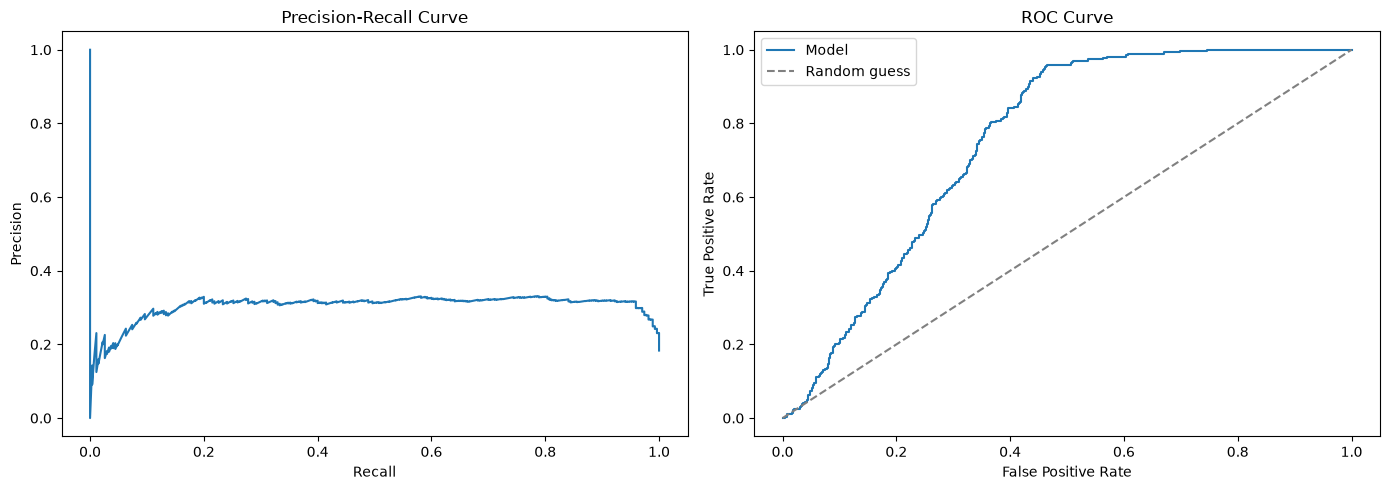

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_balanced)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba_balanced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")

axes[1].plot(fpr, tpr, label="Model")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

The model fails to reach a "highly reliable" range where precision is high, even at the cost of recall.

Let's try a more powerful model for comparison—Random Forest, which tends to capture non-linear relationships better than Logistic Regression:

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1203
           1       0.36      0.46      0.40       270

    accuracy                           0.75      1473
   macro avg       0.62      0.64      0.62      1473
weighted avg       0.78      0.75      0.76      1473

ROC-AUC: 0.766


Before deciding which one "wins," there is something more valuable to be gained from Random Forest: which variables it is using to make its decisions.

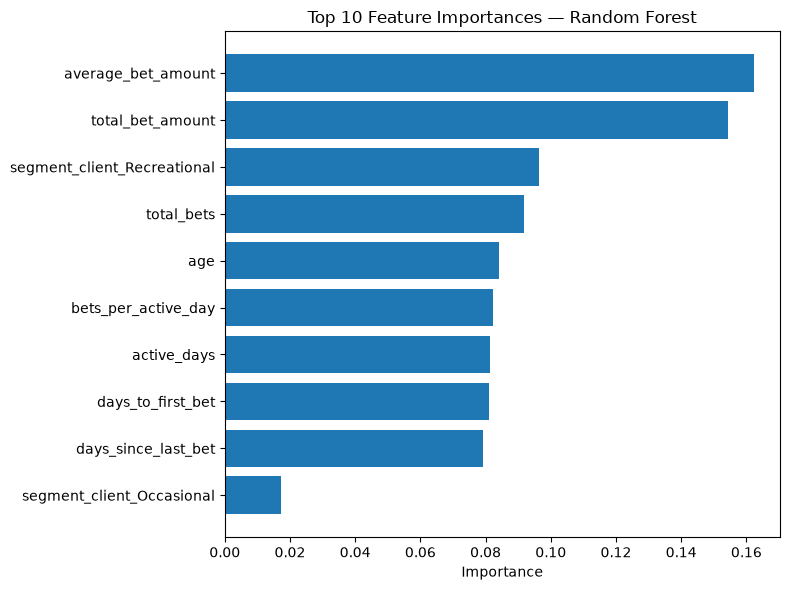

,feature,importance
3,average_bet_amount,0.162201
2,total_bet_amount,0.154218
9,segment_client_Recreational,0.096390
1,total_bets,0.091755
0,age,0.084023
6,bets_per_active_day,0.082180
4,active_days,0.081472
7,days_to_first_bet,0.080959
5,days_since_last_bet,0.079168
8,segment_client_Occasional,0.017179


In [22]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance["feature"][:10][::-1], feature_importance["importance"][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

feature_importance.head(10)

The true importance of "overall customer engagement" is distributed across several columns, not lost.

Let's quickly confirm this before moving on:

In [23]:
X_train[["total_bets", "total_bet_amount", "active_days", "bets_per_active_day", "days_since_last_bet"]].corr()

,total_bets,total_bet_amount,active_days,bets_per_active_day,days_since_last_bet
total_bets,1.000000,0.958006,0.984239,0.779891,-0.297147
total_bet_amount,0.958006,1.000000,0.901322,0.788169,-0.256442
active_days,0.984239,0.901322,1.000000,0.730455,-0.313939
bets_per_active_day,0.779891,0.788169,0.730455,1.000000,-0.339550
days_since_last_bet,-0.297147,-0.256442,-0.313939,-0.339550,1.000000


Confirmed conclusively: total_bets, total_bet_amount, and active_days are correlated between 0.90 and 0.98—they are essentially measuring the same thing three times over.

We’ll keep only `total_bet_amount` from that redundant trio (as it is the one most directly linked to business value—money wagered, rather than just an event count) and drop `total_bets` and `active_days`. This makes the model simpler and more interpretable without sacrificing actual predictive power, and prevents future misinterpretation of feature importance where one might mistakenly view them as three independent signals.

In [24]:
features_to_drop = ["total_bets", "active_days"]

X_train_v2 = X_train.drop(columns=features_to_drop)
X_test_v2 = X_test.drop(columns=features_to_drop)

rf_v2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_v2.fit(X_train_v2, y_train)

y_pred_proba_rf_v2 = rf_v2.predict_proba(X_test_v2)[:, 1]

print(f"ROC-AUC (features completas): {roc_auc_score(y_test, y_pred_proba_rf):.3f}")
print(f"ROC-AUC (features reducidas): {roc_auc_score(y_test, y_pred_proba_rf_v2):.3f}")

ROC-AUC (features completas): 0.766
ROC-AUC (features reducidas): 0.759


A minimal drop (0.007) completely acceptable in exchange for a simpler model with features that don't conflict with one another—makes for a good trade-off. We’re sticking with the streamlined version.

Now comes the part that gives this real business significance: choosing the cutoff point to determine in a production environment—whether a customer is "at risk," rather than simply accepting the default 0.5 threshold.

In [25]:
from sklearn.metrics import precision_recall_curve

precisions_v2, recalls_v2, thresholds_v2 = precision_recall_curve(y_test, y_pred_proba_rf_v2)

threshold_table = pd.DataFrame({
    "threshold": thresholds_v2,
    "precision": precisions_v2[:-1],
    "recall": recalls_v2[:-1],
})

threshold_table[threshold_table["threshold"].between(0.2, 0.6, inclusive="both")].iloc[::5]

,threshold,precision,recall
37,0.205,0.315152,0.962963
42,0.230,0.317791,0.959259
47,0.265,0.318859,0.951852
52,0.290,0.315259,0.925926
57,0.315,0.317073,0.914815
62,0.340,0.310992,0.859259
67,0.365,0.307692,0.800000
72,0.390,0.311077,0.759259
77,0.415,0.310924,0.685185
82,0.440,0.321083,0.614815


Between 0.205 and 0.315, precision remains nearly flat (~0.31–0.32) while recall drops from 0.96 to 0.91—meaning that within this range, you gain nothing tangible by raising the threshold; you simply lose recall without any offsetting benefit. A real gain in precision doesn't appear until the threshold exceeds ~0.44, at which point recall has already plummeted to 0.61.

This suggests a clear cutoff point: 0.265, where you achieve 95.2% recall with the same precision (~0.32) you would have at any lower point. There is no reason to use a threshold lower than that—you would only lose recall without gaining precision in return.

In [26]:
FINAL_THRESHOLD = 0.265

y_pred_final = (y_pred_proba_rf_v2 >= FINAL_THRESHOLD).astype(int)

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.98      0.54      0.70      1203
           1       0.32      0.95      0.48       270

    accuracy                           0.62      1473
   macro avg       0.65      0.75      0.59      1473
weighted avg       0.86      0.62      0.66      1473

[[654 549]
 [ 13 257]]


257 out of the 270 customers who actually churned were detected (95.2% recall), at the cost of 549 false positives. With this, the model is finalized: Random Forest, 6 numerical features + encoded categorical features, threshold at 0.265.

Now let's save it to disk, along with everything the future API will need to use it correctly and without ambiguity.

In [27]:
import joblib

joblib.dump(rf_v2, "churn_model.joblib")

model_metadata = {
    "feature_columns": X_train_v2.columns.tolist(),
    "threshold": FINAL_THRESHOLD,
    "cutoff_date_used_for_training": str(CUTOFF_DATE.date()),
    "churn_window_days": CHURN_WINDOW_DAYS,
    "categorical_columns_original": feature_columns_categorical,
    "test_set_metrics": {
        "roc_auc": float(roc_auc_score(y_test, y_pred_proba_rf_v2)),
        "recall_churn": 0.952,
        "precision_churn": 0.319,
    },
}

import json
with open("model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("Model and Metadata saved!")

Model and Metadata saved!


In [29]:
# Cost of failing to timely identify a customer who was going to churn:
# estimated as their average wager × an assumed future activity window (90 days)
# This is an explicit ASSUMPTION, not a measured data point—we document it as such.

ASSUMED_FUTURE_ACTIVE_DAYS = 90
FALSE_POSITIVE_COST = 40    # Asumed cost of a retention action (an e-mail, promotion, etc)

test_customers = customers_features.loc[X_test_v2.index, ["average_bet_amount", "bets_per_active_day"]].copy()
test_customers["estimated_fn_cost"] = (
    test_customers["average_bet_amount"] * test_customers["bets_per_active_day"] * ASSUMED_FUTURE_ACTIVE_DAYS
)

test_customers["estimated_fn_cost"].describe()

count      1473.000000
mean      36945.671943
std       38300.788681
min        5224.500000
25%       16056.478125
50%       19419.960000
75%       33021.068478
max      196057.009091
Name: estimated_fn_cost, dtype: float64

In [30]:
import numpy as np

thresholds_to_test = np.arange(0.1, 0.9, 0.05)

cost_results = []

for threshold in thresholds_to_test:
    predictions = (y_pred_proba_rf_v2 >= threshold).astype(int)

    false_positives_mask = (predictions == 1) & (y_test.values == 0)
    false_negatives_mask = (predictions == 0) & (y_test.values == 1)

    fp_cost = false_positives_mask.sum() * FALSE_POSITIVE_COST
    fn_cost = test_customers.loc[false_negatives_mask, "estimated_fn_cost"].sum()

    total_cost = fp_cost + fn_cost

    cost_results.append({
        "threshold": threshold,
        "false_positives": false_positives_mask.sum(),
        "false_negatives": false_negatives_mask.sum(),
        "fp_cost": fp_cost,
        "fn_cost": fn_cost,
        "total_cost": total_cost,
    })

cost_df = pd.DataFrame(cost_results)
cost_df

,threshold,false_positives,false_negatives,fp_cost,fn_cost,total_cost
0,0.10,601,9,24040,2.786563e+05,3.026963e+05
1,0.15,577,10,23080,3.103572e+05,3.334372e+05
2,0.20,565,10,22600,3.103572e+05,3.329572e+05
3,0.25,552,12,22080,3.468674e+05,3.689474e+05
4,0.30,539,20,21560,4.901237e+05,5.116837e+05
5,0.35,499,48,19960,9.573392e+05,9.772992e+05
6,0.40,430,76,17200,1.427203e+06,1.444403e+06
7,0.45,331,114,13240,2.111924e+06,2.125164e+06
8,0.50,234,155,9360,2.768253e+06,2.777613e+06
9,0.55,132,196,5280,3.427246e+06,3.432526e+06
